# Replicate Consistency Analysis

This notebook analyzes the consistency of BUSCAR's `on_score` and `off_score` metrics across experimental replicates using the CPJUMP1 dataset. It compares replicate treatment pairings against non-replicate treatment pairings (pairing different treatments) to validate that BUSCAR correctly identifies phenotypic signatures that are specific to treatments across different plates.

### Key Visualizations
- **Global Distribution Plots**: KDE plots comparing the distributions of mean `on_score` and `off_score` for real and shuffled conditions, annotated with statistical tests (Mann-Whitney U, KS test).
- **Plate-Pairing Heatmaps**: Per-treatment `ref_plate × compared_plate` matrices of mean `on_score`, shown for the top, middle, and bottom treatments by mean score.

In [50]:
import pathlib
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

PALETTE = {"real": "#2196F3", "shuffled": "#FF5722"}

In [51]:
data_dir = pathlib.Path("./results/replicate_analysis")

# Load the replicate consistency results for both real and shuffled treatments U20S cell line
u2os_rep_trt_df = pl.read_parquet(
    data_dir / "u2os_replicate_consistency_results.parquet"
)
shuffled_u2os_rep_trt_df = pl.read_parquet(
    data_dir / "u2os_random_trt_replicate_consistency_results.parquet"
)

# Load the replicate consistency results for both real and shuffled treatments A549 cell line A549
a549_rep_trt_df = pl.read_parquet(
    data_dir / "a549_replicate_consistency_results.parquet"
)
shuffled_a549_rep_trt_df = pl.read_parquet(
    data_dir / "a549_random_trt_replicate_consistency_results.parquet"
)

# output dir
output_dir = pathlib.Path("./results/replicate_analysis")

plot_output = pathlib.Path("./plots/replicate-analysis")
plot_output.mkdir(parents=True, exist_ok=True)

## Global Distribution Analysis

Compare the distributions of `on_score` and `off_score` between real and shuffled conditions across all treatments.

**Approach:** aggregate each treatment's scores (mean across all iterations and plate comparisons, excluding self-comparisons where `ref_plate_rep == compared_plate_rep`) so each treatment contributes equally to the distribution.

In [52]:
def prepare_cross_data(real_df: pl.DataFrame, shuffled_df: pl.DataFrame):
    """Label, combine, and aggregate per treatment."""
    real = real_df.with_columns(pl.lit("paired").alias("condition"))
    shuf = shuffled_df.with_columns(pl.lit("non-paired").alias("condition"))
    cross_df = pl.concat([real, shuf])
    agg_df = (
        cross_df.group_by(["condition", "treatment"])
        .agg(
            [
                pl.col("on_score").mean().alias("mean_on_score"),
                pl.col("off_score").mean().alias("mean_off_score"),
                pl.col("on_score").std().alias("std_on_score"),
                pl.col("off_score").std().alias("std_off_score"),
                pl.col("iteration").n_unique().alias("n_iterations"),
            ]
        )
        .sort(["condition", "treatment"])
    )
    real_agg = agg_df.filter(pl.col("condition") == "paired").to_pandas()
    shuf_agg = agg_df.filter(pl.col("condition") == "non-paired").to_pandas()
    return cross_df, agg_df, real_agg, shuf_agg


def run_statistical_tests(
    real_agg: pd.DataFrame, shuf_agg: pd.DataFrame
) -> pl.DataFrame:
    """Run Mann-Whitney U, KS, and Levene's tests with BH correction."""
    rows = []
    for score_col in ["mean_on_score", "mean_off_score"]:
        r, s = real_agg[score_col].dropna(), shuf_agg[score_col].dropna()
        for label, test_res in [
            ("Mann-Whitney U", stats.mannwhitneyu(r, s, alternative="two-sided")),
            ("KS test", stats.ks_2samp(r, s)),
            ("Levene's test", stats.levene(r, s, center="median")),
        ]:
            rows.append(
                {
                    "score": score_col,
                    "test": label,
                    "statistic": test_res.statistic,
                    "p_raw": test_res.pvalue,
                }
            )
    _, p_adj, _, _ = multipletests([r["p_raw"] for r in rows], method="fdr_bh")
    for row, p in zip(rows, p_adj):
        row["p_adj_BH"] = p
    return pl.DataFrame(rows)


PALETTE = {"paired": "#2196F3", "non-paired": "#FF5722"}


def plot_global_distributions(
    real_agg: pd.DataFrame,
    shuf_agg: pd.DataFrame,
    stats_df: pl.DataFrame,
    cell_type: str,
    palette: dict = PALETTE,
    save_path: pathlib.Path | None = None,
):
    """KDE of on/off score distributions with mean ± std band and p-value annotation."""
    mw_padj = {
        row["score"]: row["p_adj_BH"]
        for row in stats_df.filter(pl.col("test") == "Mann-Whitney U").iter_rows(
            named=True
        )
    }
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, score_col, title, xlabel in zip(
        axes,
        ["mean_on_score", "mean_off_score"],
        [
            "On-Score Distribution",
            "Off-Score Distribution",
        ],
        ["Mean On-Score per Treatment", "Mean Off-Score per Treatment"],
    ):
        for label, df in [("paired", real_agg), ("non-paired", shuf_agg)]:
            color = palette[label]
            mean, std = df[score_col].mean(), df[score_col].std()
            sns.kdeplot(
                data=df,
                x=score_col,
                ax=ax,
                label=label,
                color=color,
                fill=True,
                alpha=0.3,
                linewidth=2,
            )
            ax.axvline(mean, color=color, linestyle="-", linewidth=1.5, alpha=0.9)
            ax.axvspan(mean - std, mean + std, color=color, alpha=0.08)

        paired_std, nonpaired_std = real_agg[score_col].std(), shuf_agg[score_col].std()
        p = mw_padj[score_col]
        p_str = f"p = {p:.2e}" if p >= 1e-300 else "p < 1e-300"
        ax.text(
            0.97,
            0.95,
            f"Mann-Whitney U\n{p_str} (BH-adj)\n─────────────\npaired     std = {paired_std:.3f}\nnon-paired std = {nonpaired_std:.3f}",
            transform=ax.transAxes,
            fontsize=8,
            ha="right",
            va="top",
            family="monospace",
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor="white",
                edgecolor="gray",
                alpha=0.85,
            ),
        )
        ax.set_title(title, fontsize=12)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Density")
        ax.legend(title="Condition")
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

    plt.suptitle(
        f"{cell_type} Global Score Distributions (per-treatment means)",
        fontsize=13,
        y=1.02,
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_plate_pair_heatmaps(
    real_df: pl.DataFrame,
    shuffled_df: pl.DataFrame,
    agg_df: pl.DataFrame,
    cell_type: str,
    condition: str = "paired",
    save_path: pathlib.Path | None = None,
):
    """Plate-pair on_score heatmaps for top / middle / bottom treatments."""
    source_df = real_df if condition == "paired" else shuffled_df
    sorted_trts = (
        agg_df.filter(pl.col("condition") == condition)
        .sort("mean_on_score", descending=True)
        .select(["treatment", "mean_on_score"])
        .to_pandas()
    )
    _, mid = len(sorted_trts), len(sorted_trts) // 2
    selected_trts = (
        sorted_trts.iloc[:3]["treatment"].tolist()
        + sorted_trts.iloc[mid - 1 : mid + 2]["treatment"].tolist()
        + sorted_trts.iloc[-3:]["treatment"].tolist()
    )

    fig, axes = plt.subplots(3, 3, figsize=(19, 17))
    for ax, trt in zip(axes.flatten(), selected_trts):
        pivot = (
            source_df.filter(pl.col("treatment") == trt)
            .group_by(["ref_plate_rep", "compared_plate_rep"])
            .agg(pl.col("on_score").mean())
            .sort(["ref_plate_rep", "compared_plate_rep"])
            .to_pandas()
            .pivot(
                index="ref_plate_rep", columns="compared_plate_rep", values="on_score"
            )
        )
        pivot.index.name = "Reference plate"
        pivot.columns.name = "Compared plate"

        # Per-facet symmetric colorbar centered at 1
        trt_scores = pivot.values.flatten()
        trt_scores = trt_scores[~np.isnan(trt_scores)]
        vcenter = 1.0
        p5 = float(np.percentile(trt_scores, 5))
        p95 = float(np.percentile(trt_scores, 95))
        max_dev = max(abs(p95 - vcenter), abs(vcenter - p5))
        vmin, vmax = vcenter - max_dev, vcenter + max_dev

        mean_score = sorted_trts.loc[
            sorted_trts["treatment"] == trt, "mean_on_score"
        ].values[0]
        sns.heatmap(
            pivot,
            ax=ax,
            cmap="coolwarm",
            center=vcenter,
            vmin=vmin,
            vmax=vmax,
            annot=True,
            fmt=".2f",
            annot_kws={"size": 20},
            linewidths=0.4,
            cbar_kws={"shrink": 0.8},
        )

        # Draw a darker outline on diagonal cells (same plate vs same plate)
        col_labels = list(pivot.columns)
        for row_i, row_label in enumerate(pivot.index):
            if row_label in col_labels:
                col_j = col_labels.index(row_label)
                ax.add_patch(
                    mpatches.Rectangle(
                        (col_j, row_i),
                        1,
                        1,
                        fill=False,
                        edgecolor="black",
                        linewidth=3,
                        clip_on=False,
                    )
                )

        ax.set_title(f"{trt}\n(mean on_score={mean_score:.3f})", fontsize=20)
        ax.set_xlabel("Compared plate", fontsize=13, fontweight="bold")
        ax.set_ylabel("Reference plate", fontsize=13, fontweight="bold")
        ax.tick_params(labelsize=15)

    plt.suptitle(
        f"Plate-Pair {cell_type} On-Score Heatmaps {condition}-replicates (mean across iterations)",
        fontsize=18,
        y=1.01,
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


print("Functions loaded.")

Functions loaded.


In [53]:
u2os_cross_df, u2os_agg_df, u2os_real_agg, u2os_shuf_agg = prepare_cross_data(
    u2os_rep_trt_df, shuffled_u2os_rep_trt_df
)
print(
    f"Treatments (real):     {u2os_agg_df.filter(pl.col('condition') == 'real').height}"
)
print(
    f"Treatments (shuffled): {u2os_agg_df.filter(pl.col('condition') == 'shuffled').height}"
)

Treatments (real):     0
Treatments (shuffled): 0


In [54]:
a549_cross_df, a549_agg_df, a549_real_agg, a549_shuf_agg = prepare_cross_data(
    a549_rep_trt_df, shuffled_a549_rep_trt_df
)
print(
    f"Treatments (real):     {a549_agg_df.filter(pl.col('condition') == 'real').height}"
)
print(
    f"Treatments (shuffled): {a549_agg_df.filter(pl.col('condition') == 'shuffled').height}"
)

Treatments (real):     0
Treatments (shuffled): 0


In [55]:
u2os_stats_df = run_statistical_tests(u2os_real_agg, u2os_shuf_agg)

# save stats table
u2os_stats_df.write_csv(output_dir / "u2os_statistical_tests.csv", separator=",")

# Display the stats table
u2os_stats_df

score,test,statistic,p_raw,p_adj_BH
str,str,f64,f64,f64
"""mean_on_score""","""Mann-Whitney U""",13970.0,3.0248e-49,4.5372e-49
"""mean_on_score""","""KS test""",0.804636,4.3132e-98,1.2940e-97
"""mean_on_score""","""Levene's test""",228.807695,4.7752e-44,5.7303e-44
"""mean_off_score""","""Mann-Whitney U""",7601.0,2.8726e-70,5.7451e-70
"""mean_off_score""","""KS test""",0.81457,5.1404e-101,3.0842e-100
"""mean_off_score""","""Levene's test""",35.831034,3.6982e-9,3.6982e-9


In [56]:
a549_stats_df = run_statistical_tests(a549_real_agg, a549_shuf_agg)

# save stats table
a549_stats_df.write_csv(output_dir / "a549_statistical_tests.csv", separator=",")

a549_stats_df

score,test,statistic,p_raw,p_adj_BH
str,str,f64,f64,f64
"""mean_on_score""","""Mann-Whitney U""",20621.0,2.3082e-31,2.7699e-31
"""mean_on_score""","""KS test""",0.735099,1.6480e-79,4.9439e-79
"""mean_on_score""","""Levene's test""",209.977271,4.8916e-41,7.3373e-41
"""mean_off_score""","""Mann-Whitney U""",6991.0,1.7558e-72,3.5116e-72
"""mean_off_score""","""KS test""",0.758278,2.3064e-85,1.3839e-84
"""mean_off_score""","""Levene's test""",40.058141,4.8179e-10,4.8179e-10


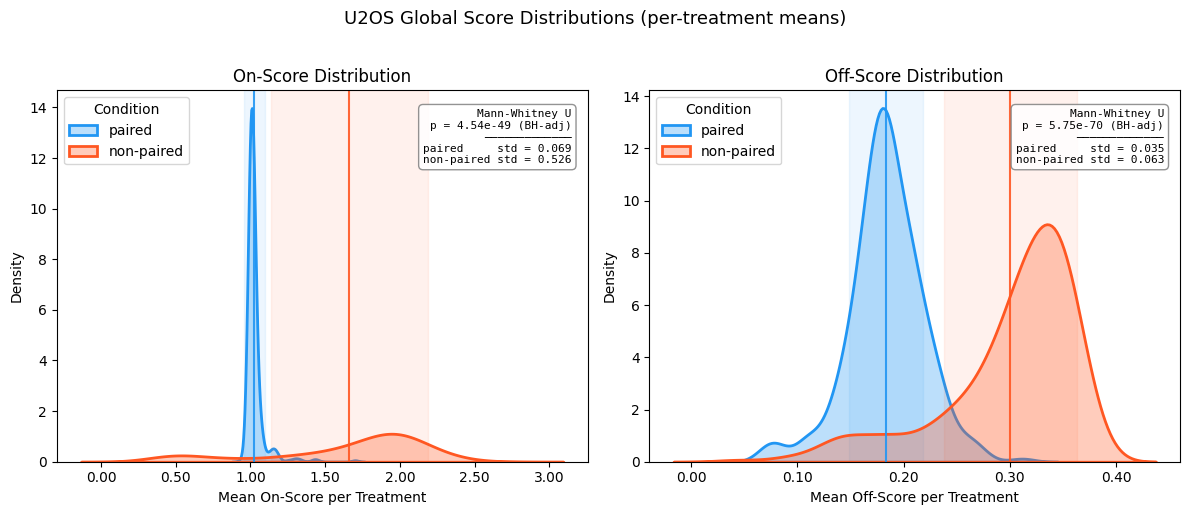

In [57]:
plot_global_distributions(
    u2os_real_agg,
    u2os_shuf_agg,
    u2os_stats_df,
    cell_type="U2OS",
    save_path=plot_output / "compound_u2os_global_score_distributions.png",
)

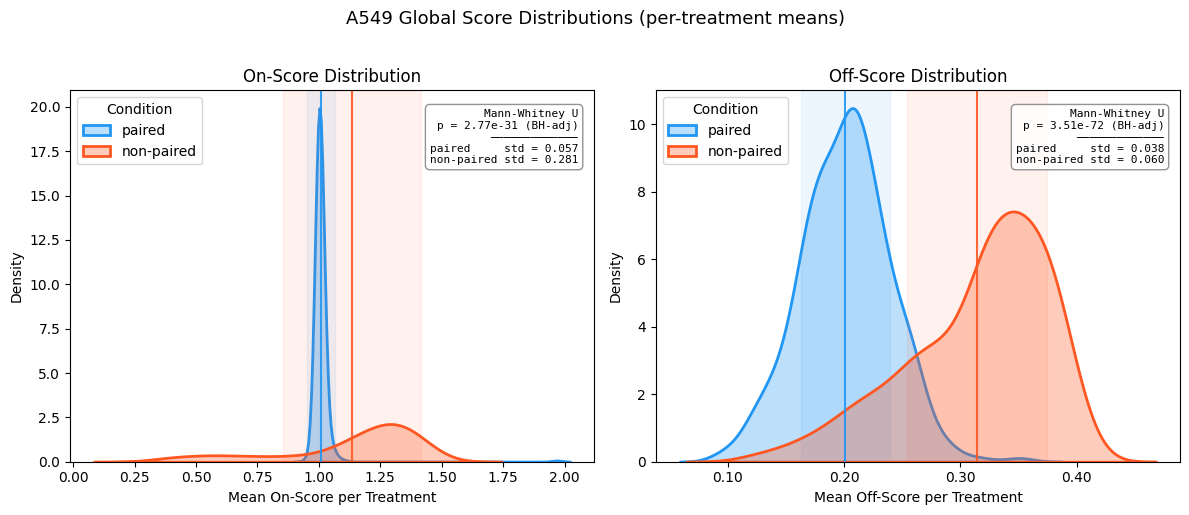

In [58]:
plot_global_distributions(
    a549_real_agg,
    a549_shuf_agg,
    a549_stats_df,
    cell_type="A549",
    save_path=plot_output / "compound_a549_global_score_distributions.png",
)

## Analysis 2 — Plate-Pair Score Heatmap

For selected treatments, build a `ref_plate × compared_plate` matrix of mean `on_score` (averaged across iterations). A well-replicated treatment should produce a near-uniform matrix (~1.0). Outlier plates appear as divergent rows or columns.

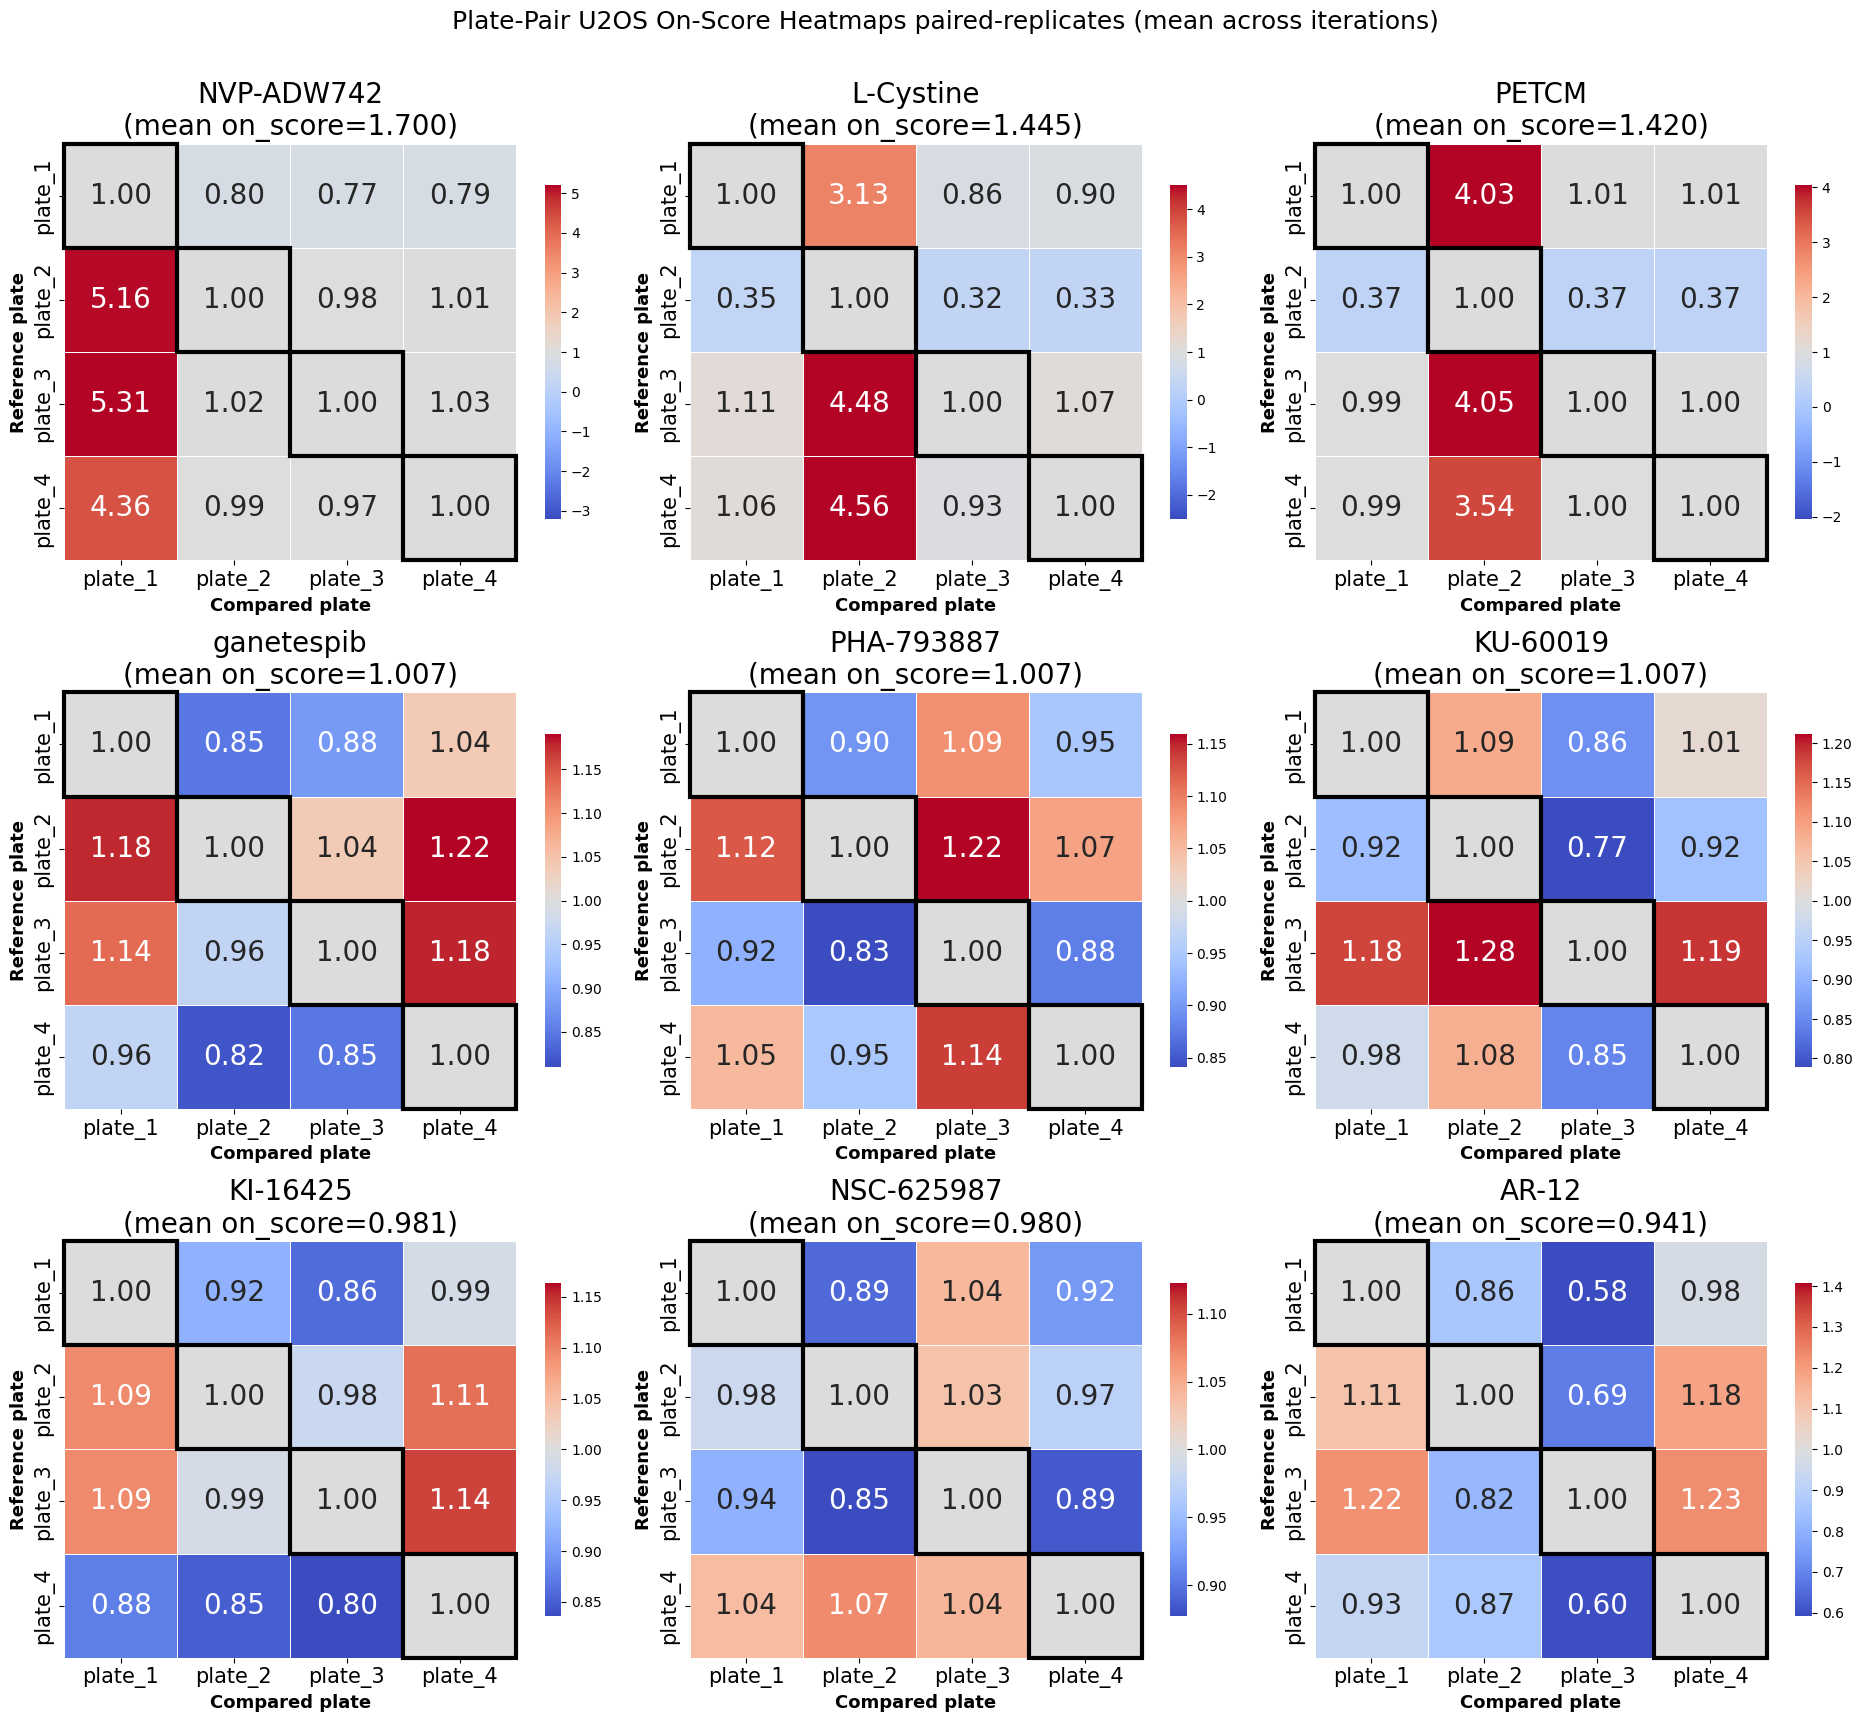

In [59]:
plot_plate_pair_heatmaps(
    u2os_rep_trt_df,
    shuffled_u2os_rep_trt_df,
    u2os_agg_df,
    cell_type="U2OS",
    condition="paired",
    save_path=plot_output / "compound_u2os_plate_pair_heatmaps_real.png",
)

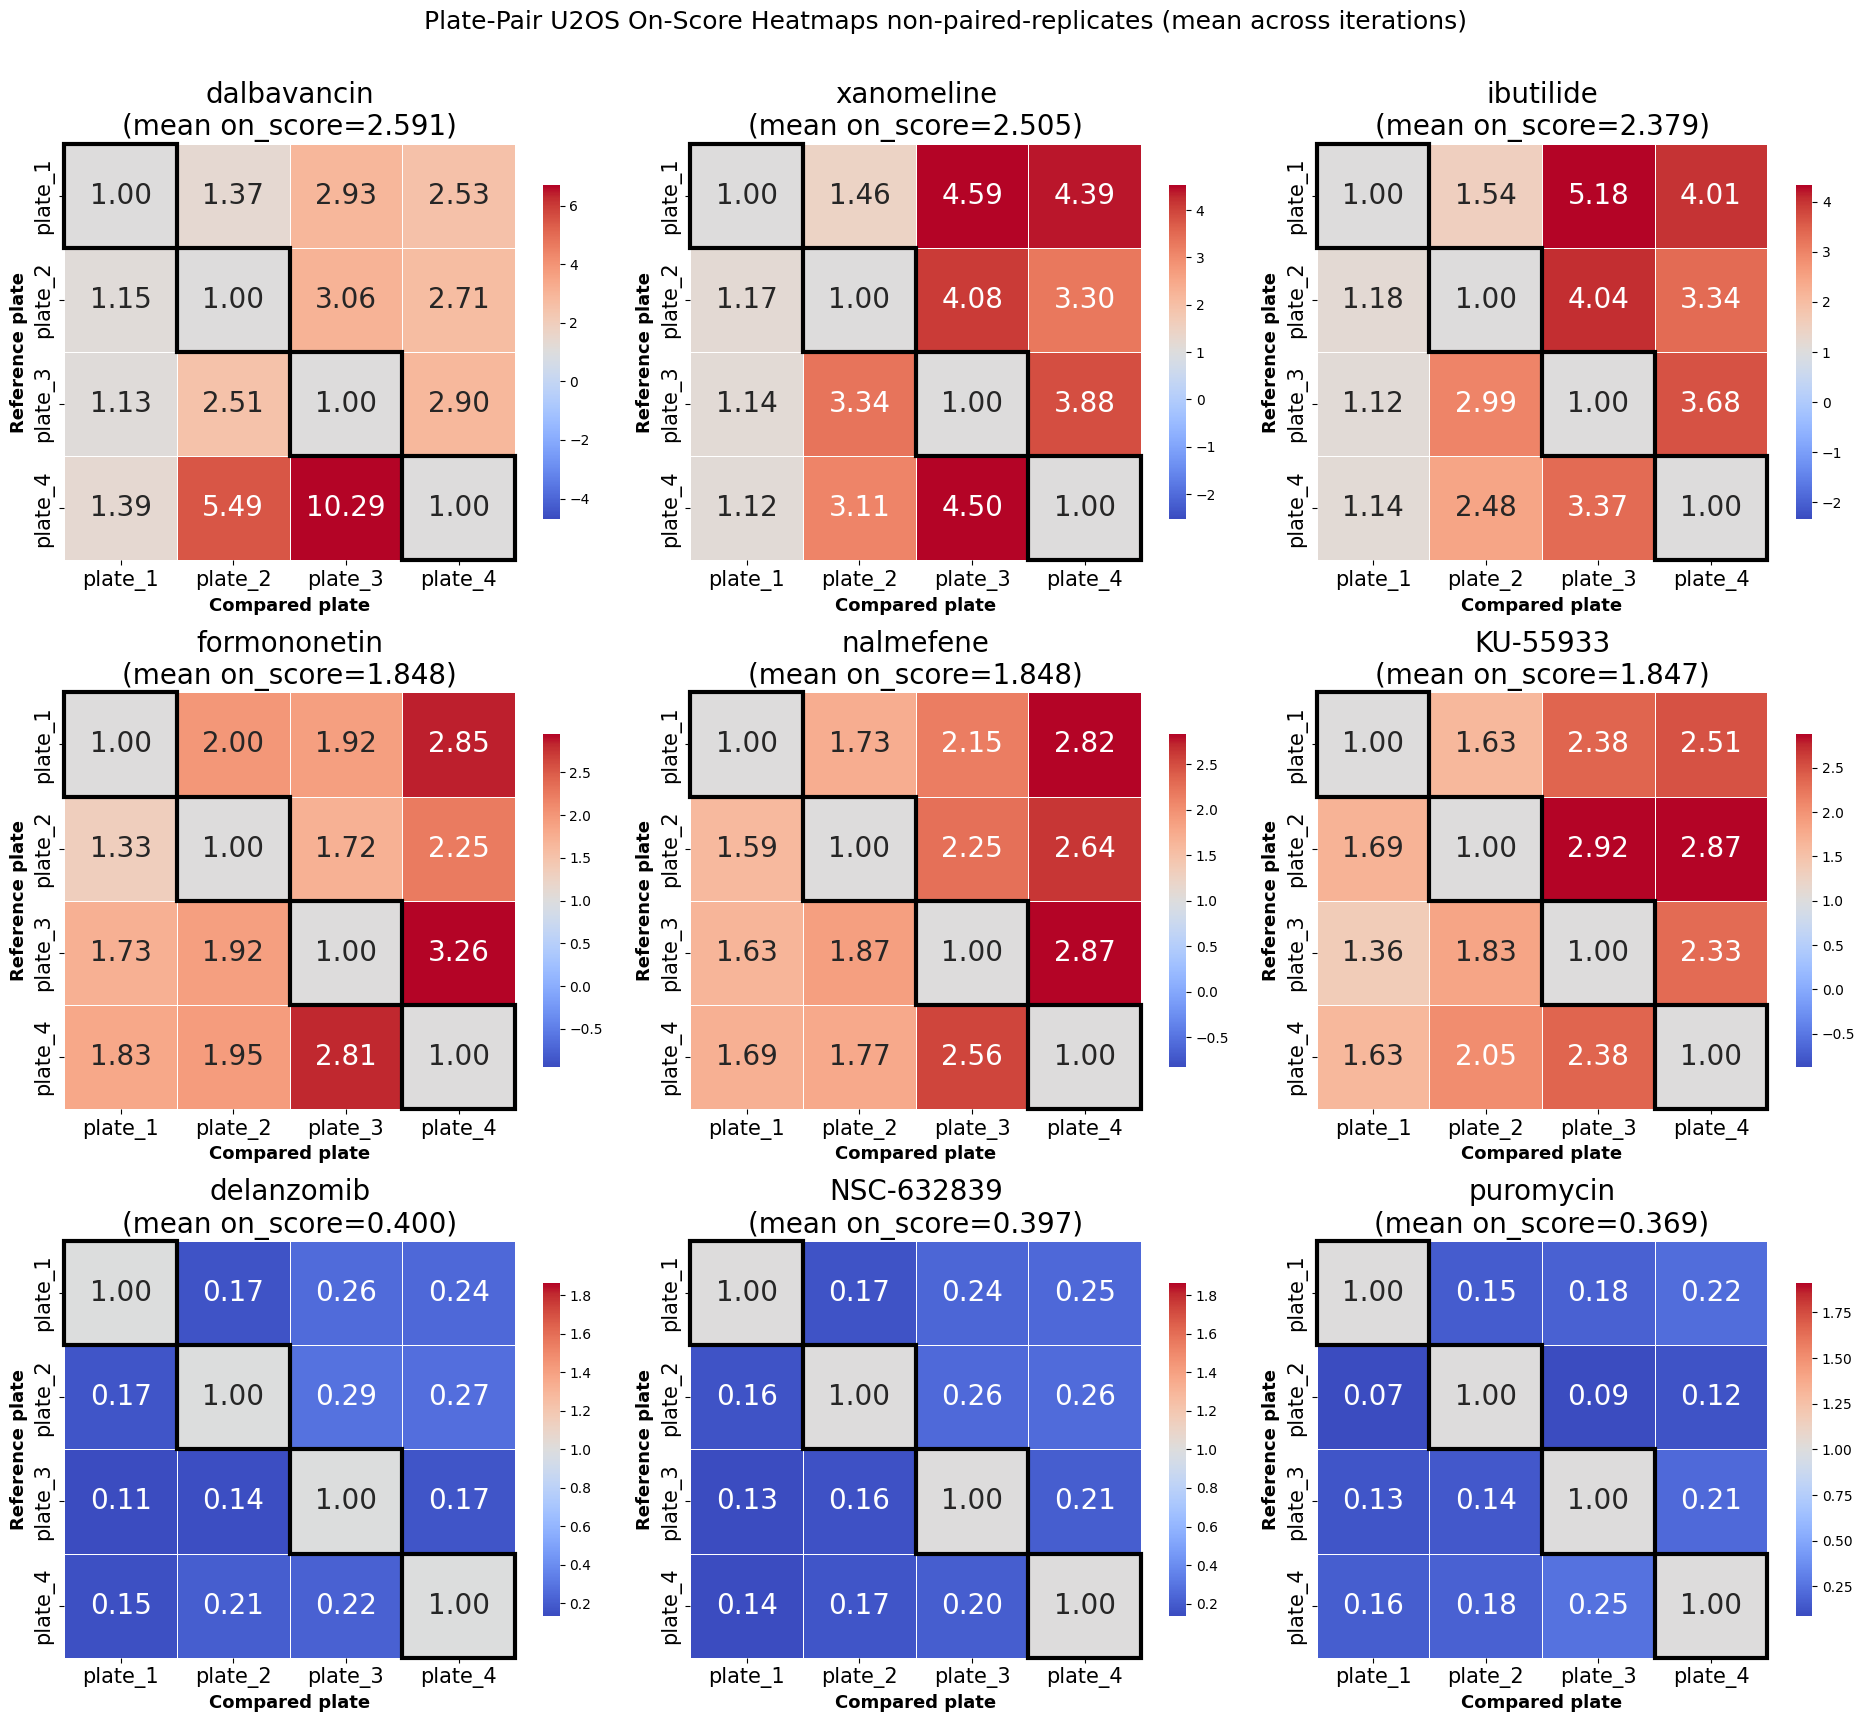

In [60]:
plot_plate_pair_heatmaps(
    u2os_rep_trt_df,
    shuffled_u2os_rep_trt_df,
    u2os_agg_df,
    cell_type="U2OS",
    condition="non-paired",
    save_path=plot_output / "compound_u2os_plate_pair_heatmaps_non_rep.png",
)

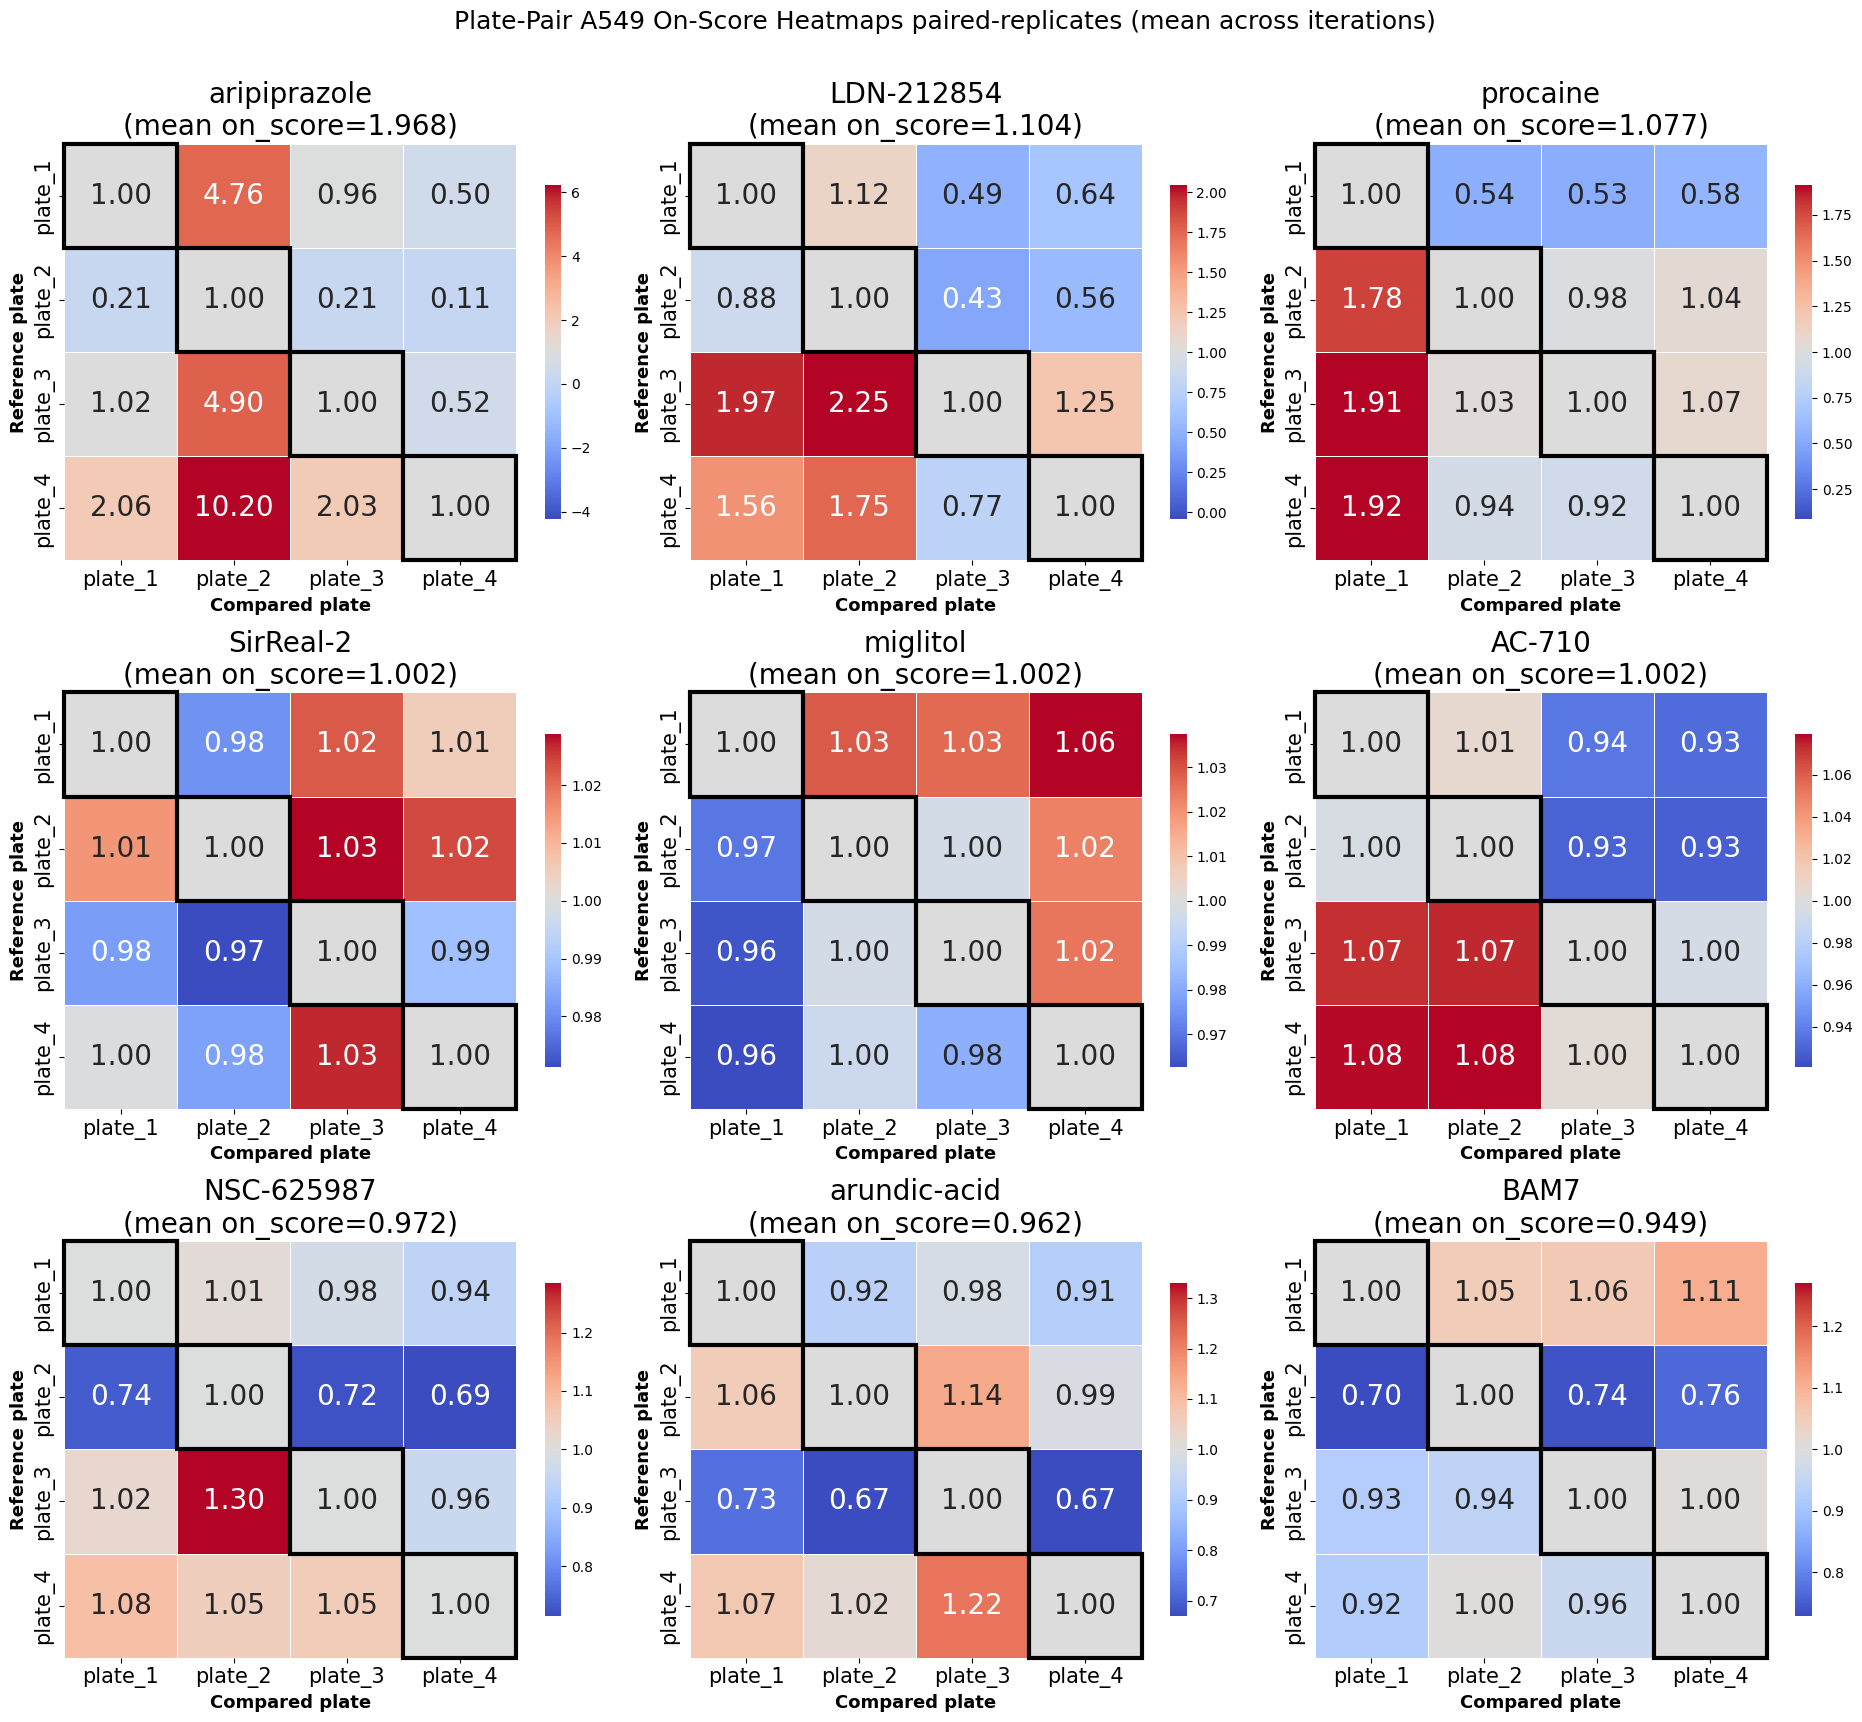

In [61]:
plot_plate_pair_heatmaps(
    a549_rep_trt_df,
    shuffled_a549_rep_trt_df,
    a549_agg_df,
    cell_type="A549",
    condition="paired",
    save_path=plot_output / "compound_a549_plate_pair_heatmaps_real.png",
)

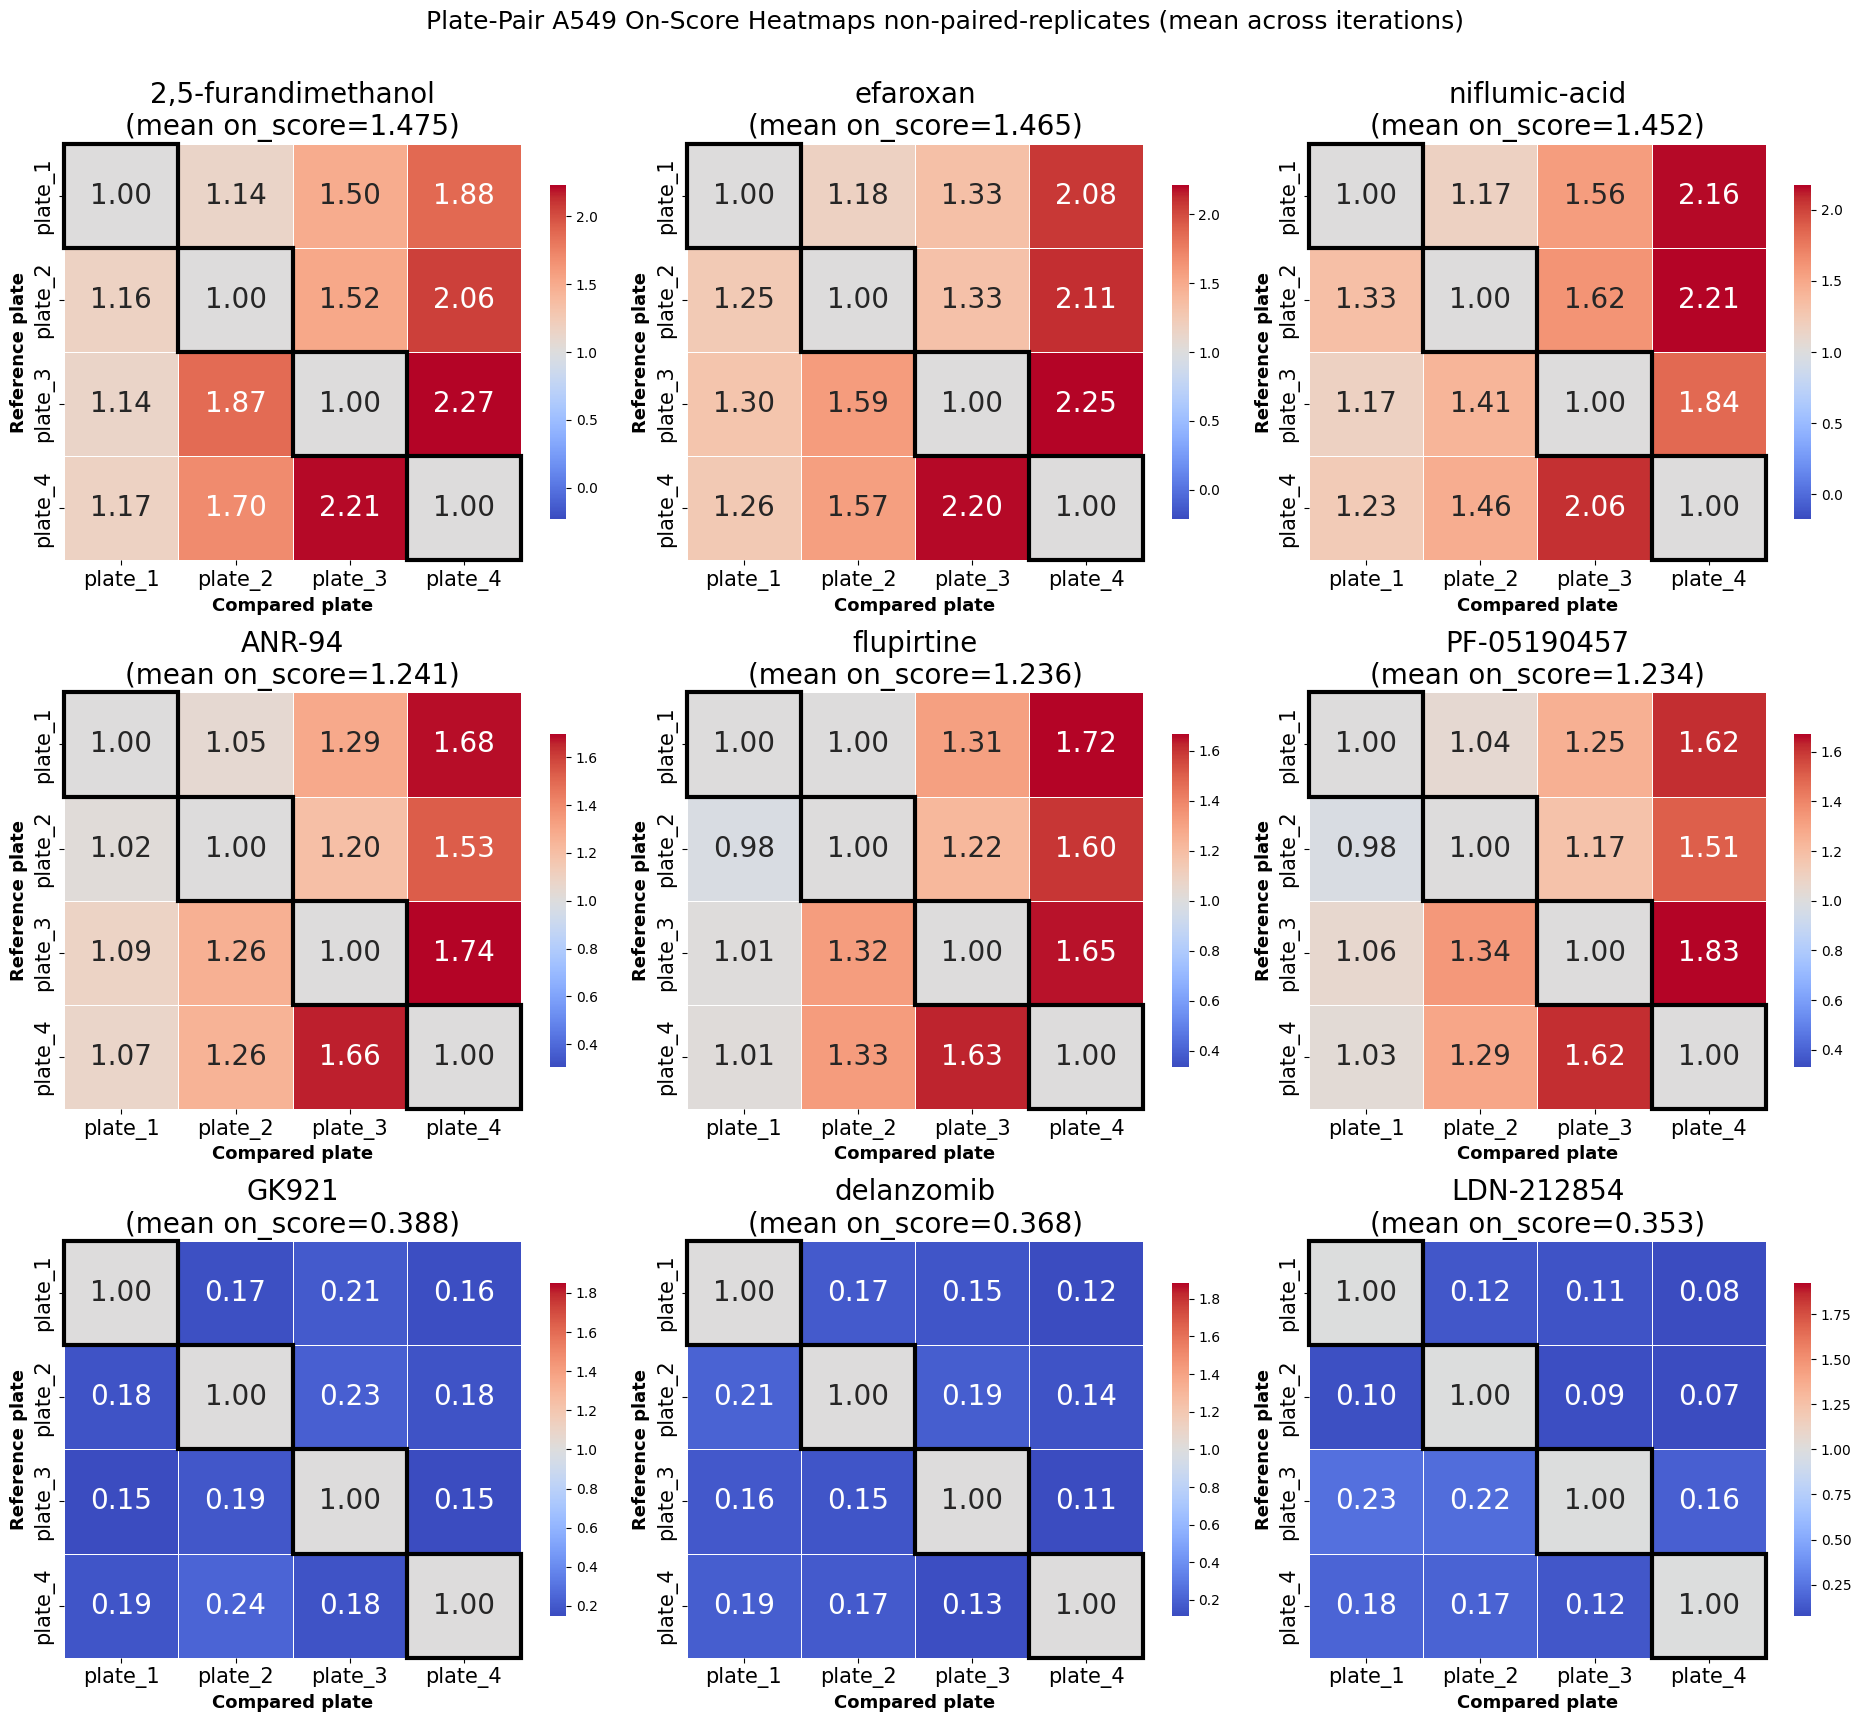

In [62]:
plot_plate_pair_heatmaps(
    a549_rep_trt_df,
    shuffled_a549_rep_trt_df,
    a549_agg_df,
    cell_type="A549",
    condition="non-paired",
    save_path=plot_output / "compound_a549_plate_pair_heatmaps_non_rep.png",
)